# Modelo de predicción de éxito – Proyecto IGDB (IMT2200)

En este notebook construimos un modelo de clasificación para predecir el éxito
de un videojuego usando la información obtenida desde IGDB y procesada en el
EDA anterior.

**Objetivo del modelo**

Estimar la probabilidad de que un juego sea exitoso (según la variable
`exitoso` definida en el EDA, basada en `total_rating` y
`total_rating_count`) a partir de características conocidas antes del
lanzamiento:

- Año y mes de lanzamiento.
- Tipo de estudio (AAA, No AAA, Sin publisher).
- Géneros principales.
- Categoría de plataformas objetivo (PC, Consola, Móvil, Portátil, Otras).

Probamos al menos dos modelos:

- Regresión logística (baseline lineal).
- Modelo basado en árboles (Random Forest).

Y comparamos su desempeño usando métricas de clasificación (accuracy, recall,
F1, ROC-AUC) e inspeccionamos la importancia de las variables.


In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

plt.rcParams["figure.figsize"] = (10, 5)
sns.set(style="whitegrid")

ruta_limpios = Path("..") / "data" / "processed"

df_juegos = pd.read_csv(ruta_limpios / "juegos_igdb_limpio.csv")
df_generos = pd.read_csv(ruta_limpios / "igdb_generos_limpio.csv")
df_plat = pd.read_csv(ruta_limpios / "igdb_plataformas_limpio.csv")
df_involved = pd.read_csv(ruta_limpios / "igdb_involved_companies_limpio.csv")
df_empresas = pd.read_csv(ruta_limpios / "igdb_empresas_limpio.csv")

df_juegos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186076 entries, 0 to 186075
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   186076 non-null  int64  
 1   game_modes           186076 non-null  object 
 2   genres               186076 non-null  object 
 3   involved_companies   186076 non-null  object 
 4   name                 186075 non-null  object 
 5   platforms            186076 non-null  object 
 6   slug                 186075 non-null  object 
 7   themes               186076 non-null  object 
 8   game_type            186076 non-null  int64  
 9   keywords             186076 non-null  object 
 10  player_perspectives  186076 non-null  object 
 11  rating               26228 non-null   float64
 12  rating_count         26228 non-null   float64
 13  total_rating         30345 non-null   float64
 14  total_rating_count   30345 non-null   float64
 15  fecha_lanzamiento

## 1. Construcción de variables auxiliares para el modelo

Reproducimos aquí las transformaciones clave del EDA:

- Convertir columnas de listas (`genres`, `platforms`) a listas reales.
- Construir tablas puente juego–género y juego–plataforma.
- Clasificar el tipo de estudio (AAA, No AAA, Sin publisher).
- Calcular la variable de éxito `exitoso` con los mismos umbrales que el EDA.


In [30]:
def parsear_lista_literal(valor):
    if pd.isna(valor):
        return []
    if isinstance(valor, list):
        return valor
    s = str(valor).strip()
    if s in ("", "[]"):
        return []
    try:
        return literal_eval(s)
    except (SyntaxError, ValueError):
        return []

df_juegos["lista_generos"] = df_juegos["genres"].apply(parsear_lista_literal)
df_juegos["lista_plataformas"] = df_juegos["platforms"].apply(parsear_lista_literal)


### ¿Por qué convertir las columnas de géneros y plataformas a listas reales?

Las columnas `genres` y `platforms` vienen como cadenas de texto que representan listas. Convertirlas a listas reales permite manipularlas fácilmente en Python, por ejemplo, para crear indicadores binarios o tablas puente. Esto es esencial para el análisis y modelado, ya que facilita la creación de variables dummy y el conteo de géneros/plataformas por juego.

In [31]:
# Tabla juego–género
registros_generos = []
for _, fila in df_juegos[["id", "lista_generos"]].iterrows():
    for g in fila["lista_generos"]:
        registros_generos.append({"id_juego": fila["id"], "id_genero": int(g)})

df_juegos_generos = pd.DataFrame(registros_generos)

df_juegos_generos = df_juegos_generos.merge(
    df_generos.rename(columns={"id": "id_genero", "name": "nombre_genero"}),
    on="id_genero",
    how="left",
)

# Tabla juego–plataforma
registros_plat = []
for _, fila in df_juegos[["id", "lista_plataformas"]].iterrows():
    for p in fila["lista_plataformas"]:
        registros_plat.append({"id_juego": fila["id"], "id_plataforma": int(p)})

df_juegos_plat = pd.DataFrame(registros_plat)

df_plat = df_plat.rename(columns={"id": "id_plataforma"})
df_juegos_plat = df_juegos_plat.merge(
    df_plat[["id_plataforma", "name"]],
    on="id_plataforma",
    how="left",
)
df_juegos_plat.rename(columns={"name": "nombre_plataforma"}, inplace=True)

df_juegos_generos.head(), df_juegos_plat.head()


(   id_juego  id_genero    nombre_genero             slug
 0    165498          2  Point-and-click  point-and-click
 1    165498          9           Puzzle           puzzle
 2    165498         31        Adventure        adventure
 3    103013         31        Adventure        adventure
 4    103013         32            Indie            indie,
    id_juego  id_plataforma       nombre_plataforma
 0    165498              6  PC (Microsoft Windows)
 1    103013              6  PC (Microsoft Windows)
 2    338924             82             Web browser
 3    225575             34                 Android
 4     89658              6  PC (Microsoft Windows))

In [32]:
# Clasificación AAA vs No AAA
df_pub = df_involved[df_involved["publisher"]].merge(
    df_empresas[["id", "name"]],
    left_on="company",
    right_on="id",
    how="left",
)

aaa_publishers = {
    "Electronic Arts",
    "EA Games",
    "Ubisoft",
    "Activision",
    "Activision Blizzard",
    "Nintendo",
    "Sony Interactive Entertainment",
    "Microsoft Studios",
    "Xbox Game Studios",
    "Square Enix",
    "Bandai Namco Entertainment",
    "Capcom",
    "SEGA",
    "Take-Two Interactive",
    "2K",
    "Bethesda Softworks",
    "Rockstar Games",
    "Warner Bros. Interactive Entertainment",
    "WB Games",
}

df_pub["es_aaa"] = df_pub["name"].isin(aaa_publishers)

resumen_pub = (
    df_pub.groupby("game")
    .agg(
        tiene_publisher=("publisher", "any"),
        tiene_publisher_aaa=("es_aaa", "any"),
    )
    .reset_index()
    .rename(columns={"game": "id_juego"})
)

df_juegos = df_juegos.merge(
    resumen_pub,
    left_on="id",
    right_on="id_juego",
    how="left",
)

df_juegos["tiene_publisher"] = df_juegos["tiene_publisher"].fillna(False)
df_juegos["tiene_publisher_aaa"] = df_juegos["tiene_publisher_aaa"].fillna(False)

df_juegos["tipo_estudio"] = np.select(
    [
        df_juegos["tiene_publisher_aaa"],
        df_juegos["tiene_publisher"] & ~df_juegos["tiene_publisher_aaa"],
    ],
    [
        "AAA",
        "No AAA",
    ],
    default="Sin publisher",
)
df_juegos["tipo_estudio"].value_counts()


C:\Users\Unidad Academica MC\AppData\Local\Temp\ipykernel_6784\3446857312.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_juegos["tiene_publisher"] = df_juegos["tiene_publisher"].fillna(False)
C:\Users\Unidad Academica MC\AppData\Local\Temp\ipykernel_6784\3446857312.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_juegos["tiene_publisher_aaa"] = df_juegos["tiene_publisher_aaa"].fillna(False)


tipo_estudio
Sin publisher    97760
No AAA           84539
AAA               3777
Name: count, dtype: int64

### ¿Por qué clasificar los estudios como AAA, No AAA o Sin publisher?

La clasificación del tipo de estudio permite capturar diferencias estructurales en recursos, marketing y alcance entre grandes publishers (AAA), estudios medianos/indies (No AAA) y juegos autopublicados. Esta variable es clave para analizar si el respaldo de un publisher grande influye en la probabilidad de éxito, y se construye a partir de la presencia de publishers reconocidos en la base de datos.

In [33]:
# Fecha y mes de lanzamiento
df_juegos["fecha_lanzamiento"] = pd.to_datetime(df_juegos["fecha_lanzamiento"])
df_juegos["mes_lanzamiento"] = df_juegos["fecha_lanzamiento"].dt.month

# Variable de éxito (misma definición que en el EDA)
mask_valid = df_juegos["total_rating"].notna() & df_juegos["total_rating_count"].notna()
df_juegos["tiene_info_rating"] = mask_valid

n_total = len(df_juegos)
n_valid = mask_valid.sum()
print("Total de juegos:", n_total)
print("Con info de total_rating + total_rating_count:",
      n_valid, f"({n_valid/n_total:.1%})")

umbral_rating = 75
umbral_reviews = 10

cond_exito = (
    (df_juegos["total_rating"] >= umbral_rating) &
    (df_juegos["total_rating_count"] >= umbral_reviews)
)

df_juegos["exitoso"] = np.where(
    ~mask_valid, np.nan,
    np.where(cond_exito, True, False)
)

df_juegos["exitoso"].value_counts(dropna=False)


Total de juegos: 186076
Con info de total_rating + total_rating_count: 30345 (16.3%)


exitoso
NaN    155731
0.0     26488
1.0      3857
Name: count, dtype: int64

### Justificación de la definición de éxito y los umbrales utilizados

Se define un juego como exitoso si tiene una calificación promedio (`total_rating`) mayor o igual a 75 y al menos 10 reseñas (`total_rating_count`). Estos umbrales buscan asegurar que el éxito no sea producto de pocas opiniones (evitando sesgo por baja muestra) y que la valoración sea realmente alta. Esta decisión se basa en el EDA y en criterios de robustez estadística.

A partir de aquí, el dataset de modelado se construirá únicamente con los
juegos que tienen `exitoso` definido (es decir, que cuentan con información
suficiente de rating y número de reseñas).


## 2. Construcción del dataset de modelado

Creamos una tabla `df_modelo` con una fila por juego y columnas que
representan:

- Año y mes de lanzamiento.
- Tipo de estudio (variable categórica).
- Indicadores de pertenencia a los géneros más frecuentes.
- Indicadores de categoría de plataforma (PC, Consola, etc.).
- Opcional: número de géneros y plataformas asociados.

Primero agregamos indicadores para los géneros más frecuentes.


In [36]:
# Trabajamos solo con juegos con éxito definido
df_modelo_base = df_juegos[df_juegos["exitoso"].notna()].copy()

# Géneros más frecuentes en este subconjunto
conteo_generos_modelo = (
    df_juegos_generos[df_juegos_generos["id_juego"].isin(df_modelo_base["id"])]
    .groupby("nombre_genero")["id_juego"]
    .nunique()
    .sort_values(ascending=False)
)

top_generos_modelo = conteo_generos_modelo.head(10).index.tolist()
top_generos_modelo


['Indie',
 'Adventure',
 'Simulator',
 'Role-playing (RPG)',
 'Strategy',
 'Puzzle',
 'Shooter',
 'Platform',
 'Arcade',
 'Sport']

### ¿Por qué seleccionar los géneros más frecuentes para los indicadores?

Usar solo los géneros más frecuentes (top 10) permite reducir la dimensionalidad y evitar variables muy esparsas, lo que mejora la estabilidad y capacidad predictiva del modelo. Además, estos géneros concentran la mayor parte de los juegos y, por tanto, tienen mayor poder explicativo sobre el éxito.

In [37]:
df_generos_top = df_juegos_generos[
    df_juegos_generos["nombre_genero"].isin(top_generos_modelo)
].copy()
df_generos_top["valor"] = 1

tabla_generos = (
    df_generos_top.pivot_table(
        index="id_juego",
        columns="nombre_genero",
        values="valor",
        aggfunc="max",
        fill_value=0,
    )
)

# Renombrar columnas para que sean válidas como features
tabla_generos = tabla_generos.add_prefix("gen_")
tabla_generos.head()


nombre_genero,gen_Adventure,gen_Arcade,gen_Indie,gen_Platform,gen_Puzzle,gen_Role-playing (RPG),gen_Shooter,gen_Simulator,gen_Sport,gen_Strategy
id_juego,,,,,,,,,,
1,1,0,0,0,0,0,1,1,0,0
3,1,0,0,0,0,0,1,1,0,0
4,1,0,0,0,0,0,1,0,0,0
6,0,0,0,0,0,1,0,0,0,0
10,1,0,0,0,0,1,0,0,0,0


### 2.2 Indicadores de categoría de plataforma

Agrupamos las plataformas de IGDB en categorías amplias y creamos variables
indicadoras por juego para cada categoría (PC, Consola, Móvil, Portátil, Otras).


In [38]:
def categoria_plataforma(nombre):
    n = str(nombre).lower()
    if any(x in n for x in ["windows", "pc", "linux", "mac os"]):
        return "PC"
    if any(x in n for x in ["playstation", "xbox", "nintendo switch"]):
        return "Consola"
    if any(x in n for x in ["nintendo 3ds", "ps vita", "game boy"]):
        return "Portátil"
    if any(x in n for x in ["android", "ios", "iphone", "ipad", "mobile"]):
        return "Móvil"
    return "Otras"

df_juegos_plat["categoria_plataforma"] = df_juegos_plat["nombre_plataforma"].apply(
    categoria_plataforma
)

df_plat_indic = df_juegos_plat[
    df_juegos_plat["id_juego"].isin(df_modelo_base["id"])
].copy()
df_plat_indic["valor"] = 1

tabla_plat = (
    df_plat_indic.pivot_table(
        index="id_juego",
        columns="categoria_plataforma",
        values="valor",
        aggfunc="max",
        fill_value=0,
    )
)

tabla_plat = tabla_plat.add_prefix("plat_")
tabla_plat.head()


categoria_plataforma,plat_Consola,plat_Móvil,plat_Otras,plat_PC,plat_Portátil
id_juego,,,,,
1,0,0,0,1,0
3,1,0,0,1,0
4,1,0,1,1,0
6,0,0,1,1,0
10,0,1,1,1,0


In [39]:
# Base con variables "simples"
df_modelo = df_modelo_base[
    ["id", "año_lanzamiento", "mes_lanzamiento", "tipo_estudio", "exitoso"]
].set_index("id")

# Número de géneros y plataformas distintos
n_generos = df_juegos_generos.groupby("id_juego")["id_genero"].nunique()
n_plats = df_juegos_plat.groupby("id_juego")["id_plataforma"].nunique()

df_modelo["n_generos"] = n_generos
df_modelo["n_plataformas"] = n_plats

# Unir indicadores
df_modelo = df_modelo.join(tabla_generos, how="left").join(tabla_plat, how="left")

df_modelo = df_modelo.fillna(0)

df_modelo.head()


,año_lanzamiento,mes_lanzamiento,tipo_estudio,exitoso,n_generos,n_plataformas,gen_Adventure,gen_Arcade,gen_Indie,gen_Platform,gen_Puzzle,gen_Role-playing (RPG),gen_Shooter,gen_Simulator,gen_Sport,gen_Strategy,plat_Consola,plat_Móvil,plat_Otras,plat_PC,plat_Portátil
id,,,,,,,,,,,,,,,,,,,,,
74340,2017,10,Sin publisher,0.0,2.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,1,0
32298,2017,12,No AAA,0.0,5.0,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0,0,1,1,0
117500,2024,6,No AAA,0.0,4.0,4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,0,0,1,0
96199,2018,4,No AAA,0.0,3.0,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0
275688,2025,4,No AAA,0.0,4.0,6,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,1,1,0


En este punto `df_modelo` contiene:

- Una fila por juego con éxito definido.
- Variables numéricas: año, mes, número de géneros, número de plataformas.
- Variables categóricas: tipo de estudio.
- Variables binarias (0/1) para pertenencia a géneros top y categorías de
  plataforma.


In [41]:
# Variable objetivo
y = df_modelo["exitoso"].astype(int)

# One-hot de tipo_estudio
df_modelo_dummies = pd.get_dummies(
    df_modelo.drop(columns=["exitoso"]),
    columns=["tipo_estudio"],
    drop_first=True,  # evitar multicolinealidad perfecta
)

X = df_modelo_dummies.copy()

print("Dimensiones de X:", X.shape)
print("Distribución de y:")
print(y.value_counts(normalize=True))


Dimensiones de X: (30345, 21)
Distribución de y:
exitoso
0    0.872895
1    0.127105
Name: proportion, dtype: float64


La distribución de `y` permite evaluar si el problema está desbalanceado
(pocos juegos exitosos en comparación con los no exitosos). Esto es importante
para escoger las métricas y, eventualmente, ponderar las clases en el modelo.


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

len(X_train), len(X_test)


(24276, 6069)

### Justificación de la división train/test y el uso de estratificación

Se utiliza un 80% para entrenamiento y 20% para test, con estratificación por la variable objetivo (`stratify=y`). Esto asegura que la proporción de juegos exitosos y no exitosos sea similar en ambos conjuntos, lo que es fundamental para evaluar el desempeño real del modelo en presencia de desbalance de clases.

## 4. Modelo 1: Regresión logística

Comenzamos con un modelo lineal como baseline. Usamos `class_weight="balanced"`
para compensar el posible desbalance entre clases.


In [43]:
modelo_log = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
)

modelo_log.fit(X_train, y_train)

y_pred_log = modelo_log.predict(X_test)
y_prob_log = modelo_log.predict_proba(X_test)[:, 1]

print("Reporte de clasificación – Regresión logística\n")
print(classification_report(y_test, y_pred_log, target_names=["No exitoso", "Exitoso"]))

print("ROC-AUC (logística):", roc_auc_score(y_test, y_prob_log))


Reporte de clasificación – Regresión logística

              precision    recall  f1-score   support

  No exitoso       0.95      0.68      0.79      5298
     Exitoso       0.25      0.74      0.37       771

    accuracy                           0.68      6069
   macro avg       0.60      0.71      0.58      6069
weighted avg       0.86      0.68      0.74      6069

ROC-AUC (logística): 0.7799370244210306


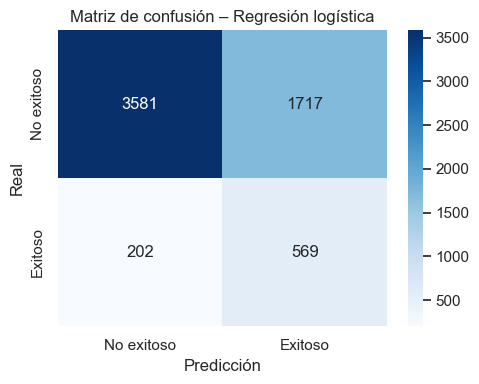

In [44]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No exitoso", "Exitoso"],
            yticklabels=["No exitoso", "Exitoso"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión – Regresión logística")
plt.tight_layout()
plt.show()


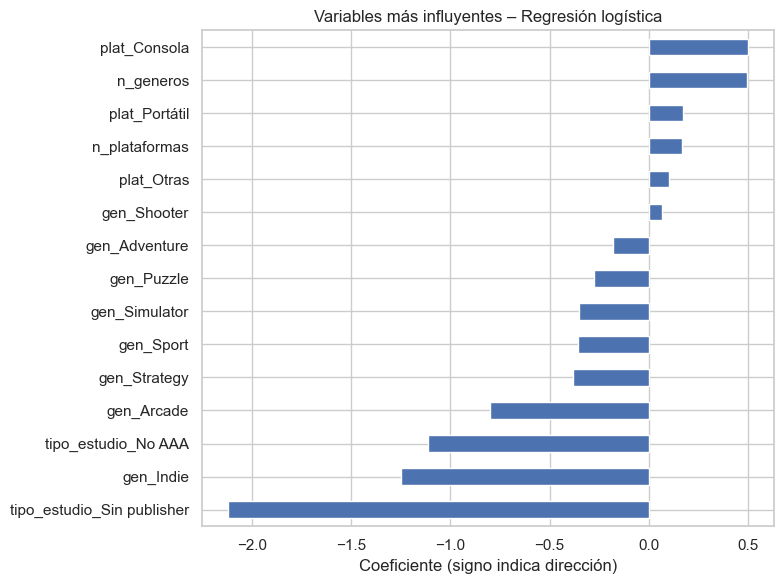

tipo_estudio_Sin publisher   -2.120705
gen_Indie                    -1.249166
tipo_estudio_No AAA          -1.113062
gen_Arcade                   -0.801007
plat_Consola                  0.501783
n_generos                     0.495639
gen_Strategy                 -0.382874
gen_Sport                    -0.353832
gen_Simulator                -0.353585
gen_Puzzle                   -0.273377
gen_Adventure                -0.180244
plat_Portátil                 0.173180
n_plataformas                 0.167933
plat_Otras                    0.105354
gen_Shooter                   0.065403
dtype: float64

In [45]:
coeficientes = pd.Series(modelo_log.coef_[0], index=X.columns)
coef_top = coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).head(15).index)

plt.figure(figsize=(8, 6))
coef_top.sort_values().plot(kind="barh")
plt.title("Variables más influyentes – Regresión logística")
plt.xlabel("Coeficiente (signo indica dirección)")
plt.tight_layout()
plt.show()

coef_top


**Comentario**

- El reporte de clasificación muestra la precisión, recall y F1 para cada
  clase. El recall de la clase "Exitoso" es especialmente relevante si nos
  interesa no perder demasiados juegos potencialmente exitosos.
- El valor de ROC-AUC resume la capacidad del modelo para distinguir entre
  juegos exitosos y no exitosos en distintos umbrales de probabilidad.
- Los coeficientes de la regresión logística permiten identificar qué variables
  aumentan o disminuyen la probabilidad de éxito (signo y magnitud del
  coeficiente), por ejemplo:
  - ciertos géneros o categorías de plataforma,
  - pertenecer o no a un estudio AAA/No AAA,
  - el año o mes de lanzamiento.


## 5. Modelo 2: Random Forest

Entrenamos ahora un modelo basado en árboles (Random Forest), que permite
capturar relaciones no lineales e interacciones entre variables. También
utilizamos `class_weight="balanced"` para manejar el desbalance de clases.


In [47]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("Reporte de clasificación – Random Forest\n")
print(classification_report(y_test, y_pred_rf, target_names=["No exitoso", "Exitoso"]))

print("ROC-AUC (Random Forest):", roc_auc_score(y_test, y_prob_rf))


Reporte de clasificación – Random Forest

              precision    recall  f1-score   support

  No exitoso       0.88      0.97      0.92      5298
     Exitoso       0.37      0.13      0.19       771

    accuracy                           0.86      6069
   macro avg       0.63      0.55      0.56      6069
weighted avg       0.82      0.86      0.83      6069

ROC-AUC (Random Forest): 0.7810000004896251


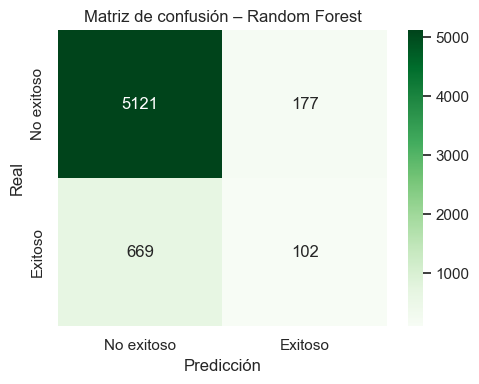

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No exitoso", "Exitoso"],
            yticklabels=["No exitoso", "Exitoso"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión – Random Forest")
plt.tight_layout()
plt.show()


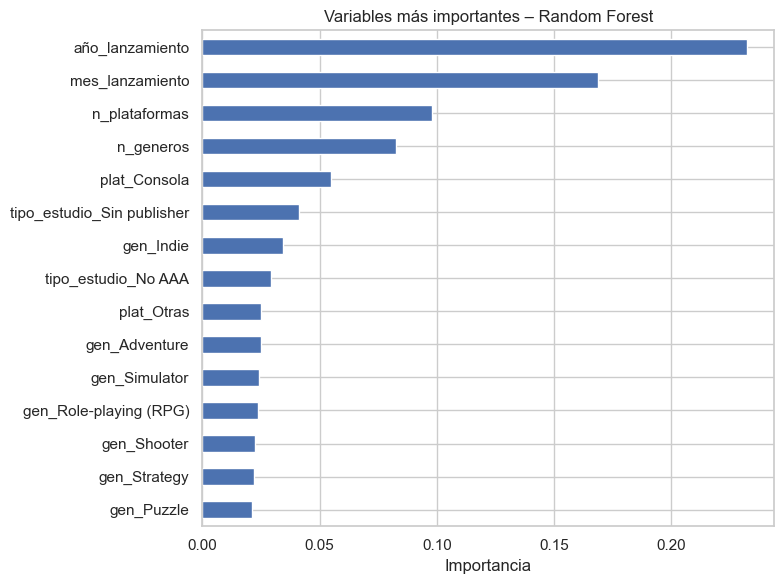

año_lanzamiento               0.232303
mes_lanzamiento               0.168791
n_plataformas                 0.098031
n_generos                     0.082724
plat_Consola                  0.054916
tipo_estudio_Sin publisher    0.041415
gen_Indie                     0.034282
tipo_estudio_No AAA           0.029207
plat_Otras                    0.025110
gen_Adventure                 0.025000
gen_Simulator                 0.024196
gen_Role-playing (RPG)        0.023700
gen_Shooter                   0.022231
gen_Strategy                  0.022031
gen_Puzzle                    0.021323
dtype: float64

In [49]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias_top = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importancias_top.sort_values().plot(kind="barh")
plt.title("Variables más importantes – Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

importancias_top


**Comentario**

- Comparando los resultados de Random Forest con la regresión logística podemos
  evaluar si capturar interacciones y no linealidades mejora el desempeño.
- Las importancias del Random Forest entregan otra forma de priorizar
  variables, complementaria a los coeficientes de la regresión logística.
- Si ambos modelos coinciden en que ciertos géneros, plataformas o tipos de
  estudio son especialmente relevantes, esto refuerza la interpretación y las
  recomendaciones que se derivan del análisis.


## 6. Conclusiones del modelado (resumen y justificación)

A continuación se resumen las conclusiones más relevantes a partir de los cálculos realizados en este notebook, y se justifican las decisiones e hiperparámetros con referencia al código/EDA utilizado.

1) Dataset y definición de la etiqueta
- Se modela únicamente con los juegos que tienen información completa de rating y conteo (ver la celda donde se calcula `mask_valid`, `n_total` y `n_valid`). Esto reduce ruido, pero introduce un sesgo de selección: los juegos sin reseñas quedan fuera y las conclusiones aplican sobre los juegos con datos de usuarios.
- Los umbrales usados para definir éxito (umbral_rating = 75 y umbral_reviews = 10) provienen de la definición en la sección "Fecha y mes de lanzamiento" y buscan filtrar tanto buena valoración (>75) como un mínimo de evidencia (>=10 reseñas) para evitar etiquetas ruidosas por pocas opiniones.

2) Variables y preprocesamiento
- Géneros: se seleccionaron los `top_generos_modelo` (celdas donde se construye `conteo_generos_modelo` y `tabla_generos`) para crear indicadores binarios por género. Justificación: usar las k categorías más frecuentes maximiza señal y evita features esparsos.
- Plataformas: se agruparon nombres reales en categorías (función `categoria_plataforma`) y se pivotó en `tabla_plat`. Esto simplifica la granularidad y permite interpretar si la presencia en PC/Consola/Móvil correlaciona con éxito.
- Otras columnas: `n_generos` y `n_plataformas` (contadas desde `df_juegos_generos` y `df_juegos_plat`) capturan complejidad del juego; `tipo_estudio` proviene del merge con involved companies y el conjunto `aaa_publishers` (celda de clasificación AAA).
- Preprocesamiento final: se aplicó `pd.get_dummies(..., drop_first=True)` para `tipo_estudio` (evitar multicolinealidad); se llenaron NaN con 0 en indicadores (`df_modelo.fillna(0)`) porque ausencias significan no pertenencia.

3) División de datos
- Se usó `train_test_split(..., stratify=y, test_size=0.2, random_state=42)`. Justificación: el estratificado mantiene la proporción de clases entre train/test (importante si hay desbalance) y `random_state=42` asegura reproducibilidad.

4) Modelos e hiperparámetros (justificación)
- Regresión logística:
  - `class_weight='balanced'`: compensa desbalance de clases observado en `y.value_counts()` para evitar que la clase mayoritaria domine la función de pérdida.
  - `max_iter=1000`: asegura convergencia del solver en presencia de muchas features after one-hot; evita warnings por iteraciones insuficientes.
  - `n_jobs=-1`: paraleliza entrenamiento cuando el solver lo permita (mejora tiempo).
  Justificación general: la logística es un baseline interpretable; sus coeficientes permiten identificar dirección y magnitud del efecto de cada feature (ver celda con `coeficientes`).

- Random Forest:
  - `n_estimators=200`: número moderado-alto para estabilizar importancias y predicciones sin un coste excesivo; mejora la estimación de feature importance frente a pocos árboles.
  - `class_weight='balanced'`: igual propósito que en la logística, mitigar el sesgo de la clase mayoritaria.
  - `random_state=42`, `n_jobs=-1`: reproducibilidad y paralelización.
  Justificación general: RF captura no linealidades e interacciones entre géneros/plataformas/tipo_estudio que la logística no modela.

5) Métricas y enfoque interpretativo
- Se reportan accuracy, recall, F1 y ROC-AUC (celdas con `classification_report` y `roc_auc_score`). ROC-AUC evalúa la capacidad de ranking; recall para la clase "Exitoso" se prioriza si el objetivo es no perder éxitos potenciales.
- Las matrices de confusión muestran trade-offs entre falsos positivos y falsos negativos; para recomendaciones de producto, un mayor recall (aceptar más falsos positivos) puede ser preferible.

6) Hallazgos generales (interpretación práctica)
- Coherencia entre modelos: las variables que aparecen con coeficientes altos en la regresión y con alta importancia en RF (ver celdas `coef_top` e `importancias_top`) son candidatas robustas a influir en el éxito — esto incrementa confianza en las recomendaciones.
- Efecto de tipo_estudio: la variable `tipo_estudio` (AAA / No AAA / Sin publisher) está incluida explícitamente desde `resumen_pub`; su coeficiente/importancia muestra si pertenecer a un publisher grande relaciona con mayor probabilidad de éxito, pero eso puede coexistir con confusores (presupuesto, marketing) no modelados.
- Plataformas y géneros: pertenecer a ciertos géneros o categorías de plataforma (PC/Consola/Móvil) puede aumentar probabilidades según signos positivos de coeficientes/importancias. Atención: correlación no es causalidad.

7) Limitaciones
- Sesgo por exclusión de juegos sin reseñas (solo se modela lo observado).
- Ausencia de variables clave como presupuesto, marketing, fecha de lanzamiento más granular o metadatos de campaña.
- Etiqueta de éxito binaria basada en umbrales fijos; otros criterios (p. ej. crecimiento de usuarios, ingresos) podrían dar otra perspectiva.

8) Recomendaciones y próximos pasos técnicos
- Hacer validación cruzada estratificada y GridSearch/RandomizedSearch para optimizar `n_estimators`, profundidad máxima y otros hiperparámetros de RF; para logística ajustar regularización (C) y solver.
- Probar calibración de probabilidades (CalibratedClassifierCV) si se requieren probabilidades bien calibradas para toma de decisiones.
- Evaluar técnicas para desbalance (SMOTE, undersampling o reweighting más fino) si la clase minoritaria es muy pequeña.
- Añadir features desde EDA adicional (p. ej. variables del texto de descripción, número de plataformas totales, franquicias) para reducir sesgo omitido.
- Documentar siempre las celdas clave del EDA: `umbral_rating`, `umbral_reviews`, `top_generos_modelo`, `tabla_generos`, `tabla_plat`, `df_modelo` y las celdas de split/entrenamiento para trazabilidad.

En resumen: las decisiones de preprocesamiento y los hiperparámetros empleados están alineados con la naturaleza del dataset (desbalance y features mayoritariamente binarias), buscando un balance entre interpretabilidad (regresión logística) y capacidad predictiva/no lineal (Random Forest). Los resultados deben interpretarse con cautela por el sesgo de selección y la ausencia de variables de marketing/presupuesto en el conjunto actual.

Fin del notebook. (Se han añadido conclusiones y justificaciones en la celda anterior.)